In [9]:
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectPercentile, chi2

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
data = pd.read_excel("../data/job_classification.ods", engine = "odf", dtype = str)

In [3]:
data = data.dropna(axis = 0)

In [4]:
def filler_location(location):
    result = re.findall("\\,\\s[A-Z]{2}$", location)
    if len(result) > 0:
        return result[0][2:]
    else:
        return location


data["location"] = data["location"].apply(filler_location)

In [6]:
target = "career_level"
x = data.drop(target, axis = 1)
y = data[target]

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

In [8]:
transformers = ColumnTransformer(transformers = [
    ("title", TfidfVectorizer(stop_words="english"), "title"),
    ("location", OneHotEncoder(handle_unknown="ignore"), ["location"]),
    ("description", TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df = 0.01, max_df = 0.95), "description"),
    ("function", OneHotEncoder(handle_unknown="ignore"), ["function"]),
    ("industry", TfidfVectorizer(stop_words="english"), "industry")
])

In [10]:
final_model = Pipeline(steps=[
    ("transformer", transformers),
    ("feature_selector", SelectPercentile(chi2, percentile = 5)),
    ("classifier", LinearSVC(class_weight = "balanced")),
])

In [12]:
final_model.fit(x_train, y_train)

y_predict = final_model.predict(x_test)

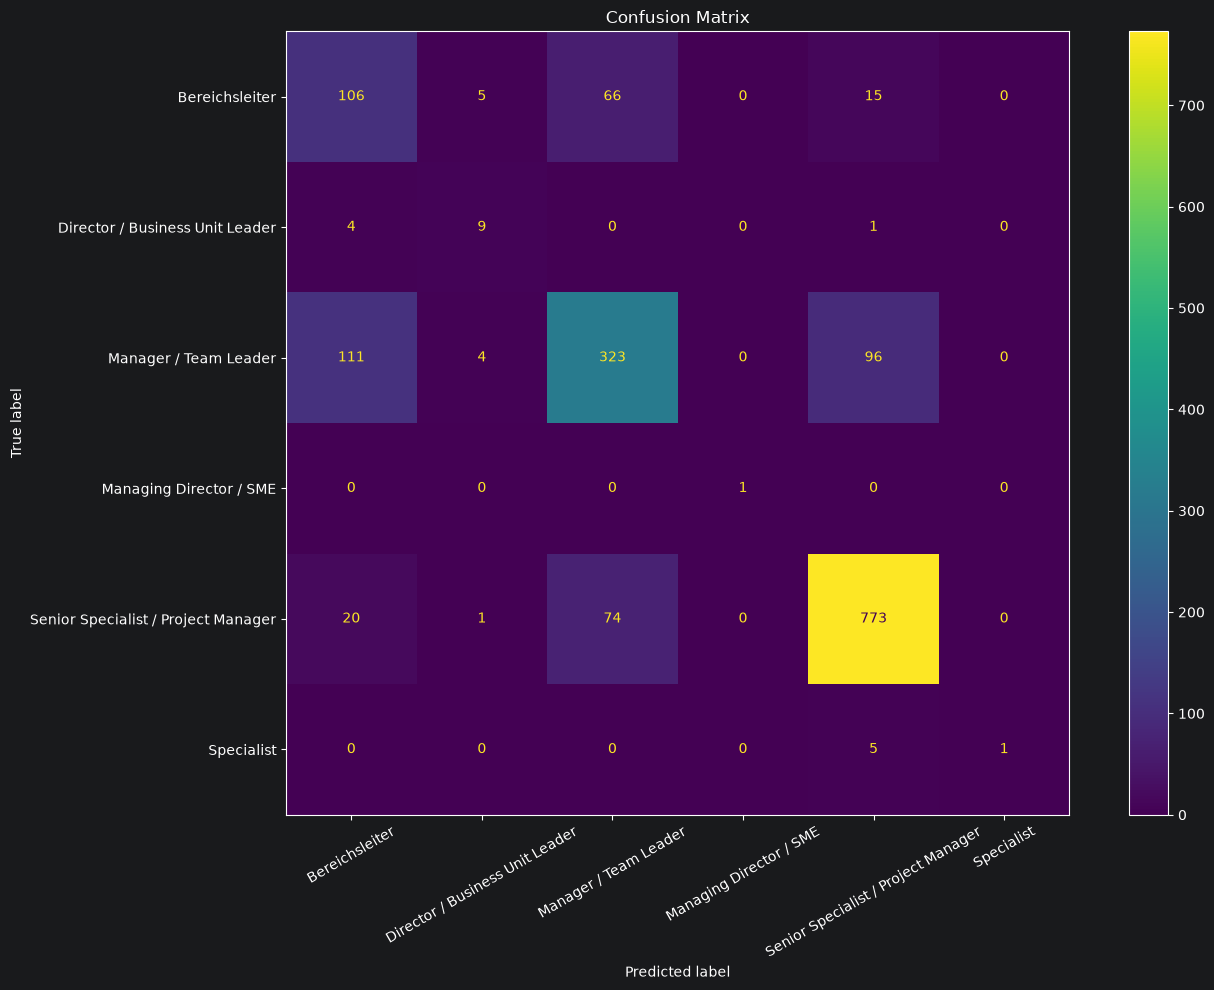

In [13]:
cm = confusion_matrix(y_test, y_predict)

labels = [
    "Bereichsleiter",
    "Director / Business Unit Leader",
    "Manager / Team Leader",
    "Managing Director / SME",
    "Senior Specialist / Project Manager",
    "Specialist"
]

fig, ax = plt.subplots(figsize=(14, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=30
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [14]:
error_analysis = x_test.copy()

error_analysis["actual"] = y_test
error_analysis["predicted"] = y_predict

errors = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
].copy()

errors.head()

,title,location,description,function,industry,actual,predicted
6612,Project Manager,NV,Dimensions:Â·Â Â Â Â Â Â Â Â Direct the Devel...,production_manufacturing,Mining and Quarrying,bereichsleiter,senior_specialist_or_project_manager
742,VP Account Director,IL,Weâ€™re searching for a Vice President/Directo...,marketing,Direct Marketing / CRM,manager_team_leader,bereichsleiter
2049,"Global Director, Sales Excellence",OH,"Key Job Responsibilities:The Global Director, ...",sales,Manufacture of Paper and Printing Products,bereichsleiter,manager_team_leader
7635,"Vice President, Senior Product Manager-Multi A...",CA,Franklin Templeton Investments is a leading gl...,marketing,Investment Banking,manager_team_leader,bereichsleiter
3810,Proposal Manager,VA,Alstom has the industryâ€™s most comprehensive...,procurement_materials_logistics,Geothermal Energy,bereichsleiter,manager_team_leader


In [15]:
confusion_pairs = (
    errors
    .groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusion_pairs.head(10)

,actual,predicted,count
5,manager_team_leader,bereichsleiter,111
7,manager_team_leader,senior_specialist_or_project_manager,96
10,senior_specialist_or_project_manager,manager_team_leader,74
1,bereichsleiter,manager_team_leader,66
8,senior_specialist_or_project_manager,bereichsleiter,20
2,bereichsleiter,senior_specialist_or_project_manager,15
11,specialist,senior_specialist_or_project_manager,5
0,bereichsleiter,director_business_unit_leader,5
3,director_business_unit_leader,bereichsleiter,4
6,manager_team_leader,director_business_unit_leader,4


In [16]:
manager_errors = errors[
    (errors["actual"] == "manager_team_leader") &
    (errors["predicted"] == "senior_specialist_or_project_manager")
]

manager_errors[
    ["title", "description", "function", "industry"]
].head(10)

,title,description,function,industry
2627,Lead Project Manager-Technical Email and SMS P...,This role will be responsible for the technica...,information_technology_telecommunications,Financial Services
374,Sr. Manager Sales Education,Empowering healthcare starts with you. At McKe...,sales,Software Companies
1253,Supervisory Management & Program Analyst,Incumbent is responsible for directing and mon...,production_manufacturing,"Administration, Civil Service"
4253,Strategic Vendor Relationship Assistant Director,Serves as a trusted advisor to senior leadersh...,sales,Financial Services
2585,"Regional Vice President, Surgical Sales","Hartford, CTÂ - The Regional Vice President, S...",sales,Optoelectronic Equipment
7599,Sales Directo,The Sales Director leads the Sales Organizatio...,sales,Supplier of Automotive Components
4913,National Accounts Manager,The National Accounts Manager will have respon...,sales,Wired and Radio Communication Technology
4160,Business Development Manager,PRIMARY DUTIES:Responsible for achieving month...,sales,Consumer Goods Manufacturing
7510,Divisional Sales Manager - West Region,The primary role of this position is to implem...,sales,Equipment for Measuring and Process Control
6747,Head of Sales and Business Development Mexico,"Soitec is an international company, a world le...",sales,Semiconductor Production


In [17]:
senior_errors = errors[
    (errors["actual"] == "senior_specialist_or_project_manager") &
    (errors["predicted"] == "manager_team_leader")
]

senior_errors[
    ["title", "description", "function", "industry"]
].head(10)

,title,description,function,industry
6086,"Director, Client Development",Major Purpose of the Position:Responsible for ...,sales,E-Commerce Services
4682,Global Medical Affairs Category Head,This is a medical affairs leadership role that...,research_development,Pharmaceutical Industry
426,Account Supervisor - Digital - PR,Edelman is looking for a motivated and high-en...,sales,"Advertising, PR"
6591,Director of Risk and Compliance,This is your opportunity to take ownership and...,finance_accounting,Software Companies
6473,USG Business Development Manger - Maintenance ...,Perform as a member of the integrated SAS US G...,sales,Aircraft Manufacturing
2964,Program Solutions Manager,NCI: As the Program Solutions Manager ( Progra...,consulting,IT Consulting
624,Principal Technical Program Manager - Fire TV,"As a Principal Technical Program Manager, you...",research_development,"Mobile Telephones, Hand-Held Computers"
5067,Professional IT Support,Technical support and service excellence for G...,information_technology_telecommunications,Telecommunications
6716,Commercial Manager,The main purpose of this role is to secure del...,sales,Transport and Tourism
5062,Professional Development Manager,"DLA Piper, a leader in the practice of law wor...",consulting,Business Consulting


In [18]:
manager_errors[
    ["title", "actual", "predicted"]
].head(20)
senior_errors[
    ["title", "actual", "predicted"]
].head(20)

,title,actual,predicted
6086,"Director, Client Development",senior_specialist_or_project_manager,manager_team_leader
4682,Global Medical Affairs Category Head,senior_specialist_or_project_manager,manager_team_leader
426,Account Supervisor - Digital - PR,senior_specialist_or_project_manager,manager_team_leader
6591,Director of Risk and Compliance,senior_specialist_or_project_manager,manager_team_leader
6473,USG Business Development Manger - Maintenance ...,senior_specialist_or_project_manager,manager_team_leader
2964,Program Solutions Manager,senior_specialist_or_project_manager,manager_team_leader
624,Principal Technical Program Manager - Fire TV,senior_specialist_or_project_manager,manager_team_leader
5067,Professional IT Support,senior_specialist_or_project_manager,manager_team_leader
6716,Commercial Manager,senior_specialist_or_project_manager,manager_team_leader
5062,Professional Development Manager,senior_specialist_or_project_manager,manager_team_leader
